In [13]:
from architectures.poolformer import poolformer_s12
import torch

model = poolformer_s12(True)

params = torch.cat([p.flatten() for p in model.parameters() if p.requires_grad]).detach()

In [14]:
stats = {
    'mean': params.mean(),
    'std': params.std(),
    'min': params.min(),
    'max': params.max(),
    '0.5_percentile': params.quantile(0.005),
    '99.5_percentile': params.quantile(0.995),
}
print(stats)

{'mean': tensor(0.0010), 'std': tensor(0.1631), 'min': tensor(-17.2902), 'max': tensor(20.1362), '0.5_percentile': tensor(-0.2745), '99.5_percentile': tensor(0.2700)}


In [15]:
p_clamped = torch.clamp(params, stats['0.5_percentile'], stats['99.5_percentile'])
clamped_stats = {
    'mean': p_clamped.mean(),
    'std': p_clamped.std()
}
print(clamped_stats)

{'mean': tensor(0.0001), 'std': tensor(0.0940)}


<Axes: ylabel='Count'>

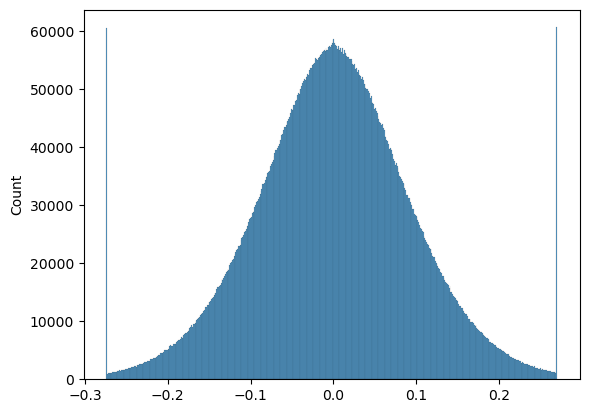

In [17]:
import seaborn as sns

sns.histplot(p_clamped)